<a href="https://colab.research.google.com/github/nuraini2502/MachineLearning/blob/Praktikum7/praktikumMandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pemodelan Regresi Linear

Nama : Nuraini

NIM : 0110222170

Matkul : Machine Learning | Sesi Pagi

# Loading Data

In [1]:
# Menyambungkan google drive
from google.colab import drive
drive.mount('/content/gdrive')
import os

# Memanggil dataset melalui gdrive
path = "gdrive/MyDrive/MachineLearning/Praktikum/data/week7/"

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
# Memanggil library yang dibutuhkan
import pandas as pd # membaca, mengolah, dan menganalisis data tabel (DataFrame).
import numpy as np # perhitungan numerik seperti array, statistik, dan operasi matematika.
import statsmodels.api as sm # analisis statistik dan regresi (memberikan hasil lengkap seperti p-value, t-stat, R², dll).
import matplotlib.pyplot as plt # visualisasi grafik dasar (line, scatter, histogram, dll).
import seaborn as sns # menampilkan visualisasi data matplotlib.
from sklearn.model_selection import train_test_split # membagi dataset menjadi data latih dan uji.
from sklearn.metrics import mean_squared_error, r2_score # mengukur performa model (MSE, R², dll).
from sklearn.linear_model import LinearRegression # membangun model regresi sederhana

In [3]:
# Menampilkan 5 baris pertama pada data
df = pd.read_csv(path + 'dataset_satelit.csv')
df.head()

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


# Mengenali Dataset

In [4]:
df.info() # menampilkan informasi ringkas tentang struktur DataFrame di pandas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         594 non-null    int64  
 1   Longitude  594 non-null    float64
 2   Lattitude  594 non-null    float64
 3   N          594 non-null    float64
 4   P          594 non-null    float64
 5   K          593 non-null    float64
 6   Ca         594 non-null    float64
 7   Mg         594 non-null    object 
 8   Fe         594 non-null    float64
 9   Mn         594 non-null    float64
 10  Cu         594 non-null    float64
 11  Zn         594 non-null    float64
 12  B          594 non-null    float64
 13  b12        594 non-null    float64
 14  b11        594 non-null    float64
 15  b9         594 non-null    float64
 16  b8a        594 non-null    float64
 17  b8         594 non-null    float64
 18  b7         594 non-null    float64
 19  b6         594 non-null    float64
 20  b5        

In [5]:
df.describe()
# menampilkan ringkasan statistik deskriptif dari kolom-kolom numerik dalam DataFrame.

,No,Longitude,Lattitude,N,P,K,Ca,Fe,Mn,Cu,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
count,594.000000,594.000000,594.000000,594.000000,594.000000,593.000000,594.000000,594.000000,594.000000,594.000000,...,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000
mean,297.500000,106.878644,-1.024933,2.259091,0.141380,0.582175,0.595094,74.613771,308.034697,2.391195,...,0.177291,0.234474,0.102789,28.640422,28.664891,28.609569,0.202587,0.051524,0.269642,0.062320
std,171.617307,4.949840,0.965349,0.395499,0.019782,0.222567,0.366118,55.579655,241.731643,1.580296,...,0.155615,0.070516,0.112310,15.325347,15.380384,15.329170,0.104357,0.012959,0.143728,0.024218
min,1.000000,102.760857,-2.333750,1.140000,0.090000,0.122000,0.050000,21.080000,3.160000,0.090000,...,0.014100,0.115170,0.021460,0.127000,0.098600,0.026000,0.008700,0.016900,0.009300,0.016300
25%,149.250000,102.927811,-2.233338,1.982500,0.130000,0.429000,0.320000,40.705000,124.015000,1.172500,...,0.046925,0.183210,0.039535,31.959745,31.968948,33.685353,0.183085,0.040250,0.244935,0.052772
50%,297.500000,103.581969,-0.602276,2.280000,0.140000,0.549000,0.540000,65.650000,239.445000,2.225000,...,0.072700,0.213385,0.046550,35.067930,35.110415,34.611565,0.233590,0.050415,0.310380,0.068380
75%,445.750000,113.403797,-0.257349,2.570000,0.150000,0.710000,0.790000,87.372500,434.990000,3.357500,...,0.318900,0.262242,0.059190,38.319135,38.441065,39.002760,0.271790,0.060410,0.364505,0.079020
max,594.000000,113.434700,0.069251,3.230000,0.220000,1.489000,2.820000,559.100000,2009.320000,8.170000,...,0.751400,0.512210,0.373000,47.592900,48.014640,39.209330,0.658960,0.122300,0.814170,0.150620


In [6]:
df.isnull().sum()
# mengecek jumlah data kosong (NaN) di setiap kolom pada DataFrame

,0
No,0
Longitude,0
Lattitude,0
N,0
P,0
K,1
Ca,0
Mg,0
Fe,0
Mn,0


In [7]:
print(df.columns) # mencetak daftar nama semua kolom yang ada di DataFrame

Index(['No', 'Longitude', 'Lattitude', 'N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn',
       'Cu', 'Zn', 'B', 'b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5',
       'b4', 'b3', 'b2', 'b1', 'Sigma_VV', 'Sigma_VH', 'plia', 'lia', 'iafe',
       'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh'],
      dtype='object')


# Pemilihan Fitur

In [8]:
# Tentukan fitur dan target
X = df[['b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5',
       'b4', 'b3', 'b2', 'b1', 'Sigma_VV', 'Sigma_VH', 'plia', 'lia', 'iafe',
       'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh']]
y = df['N']


# Bagi data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Menampilkan jumlah total data train dan data test
print(f"Jumlah data train: {len(X_train)}") # melatih model
print(f"Jumlah data test: {len(X_test)}") # menguji model

Jumlah data train: 475
Jumlah data test: 119


# Pembuatan Model

In [10]:
# Buat model regresi linear
model = LinearRegression() # inisialisasi model regresi linear
model.fit(X_train, y_train) # melatih model menggunakan data training

LinearRegression()

In [11]:
# Menambahkan konstanta (intercept) pada data fitur
X = sm.add_constant(X)

# Membuat dan melatih model regresi OLS (Ordinary Least Squares)
model_ols = sm.OLS(y_train, X_train).fit()

In [12]:
print("\n--- RINGKASAN MODEL OLS ---")
print(model_ols.summary()) # Menampilkan tabel statistik lengkap hasil regresi
print("-" * 40)


--- RINGKASAN MODEL OLS ---
                                 OLS Regression Results                                
Dep. Variable:                      N   R-squared (uncentered):                   0.988
Model:                            OLS   Adj. R-squared (uncentered):              0.987
Method:                 Least Squares   F-statistic:                              1756.
Date:                Wed, 05 Nov 2025   Prob (F-statistic):                        0.00
Time:                        15:42:41   Log-Likelihood:                         -18.170
No. Observations:                 475   AIC:                                      78.34
Df Residuals:                     454   BIC:                                      165.8
Df Model:                          21                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
------------

In [13]:
# Memprediksi nilai target pada data uji
y_pred = model.predict(X_test)

# Hitung metrik evaluasi
r2 = r2_score(y_test, y_pred) # Nilai R² (seberapa baik model menjelaskan data)
mse = mean_squared_error(y_test, y_pred) # Rata-rata kuadrat error
rmse = np.sqrt(mse)

print("\n📈 Hasil Evaluasi Model Regresi Linear:")
print(f"R² Score  : {r2:.3f}")    # Menampilkan R² dengan 3 angka di belakang koma
print(f"MSE        : {mse:.5f}")  # Menampilkan MSE dengan 5 angka di belakang koma
print(f"RMSE       : {rmse:.5f}") # Menampilkan RMSE dengan 5 angka di belakang koma


📈 Hasil Evaluasi Model Regresi Linear:
R² Score  : 0.554
MSE        : 0.06748
RMSE       : 0.25977


# Visualisasi hasil perbandingan

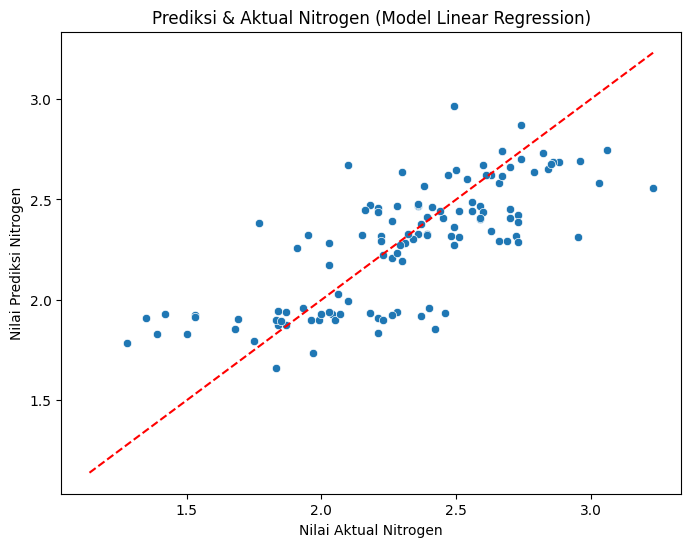

In [14]:
# Membuat scatter plot antara nilai aktual dan prediksi
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred) # Titik-titik perbandingan aktual vs prediksi
plt.xlabel('Nilai Aktual Nitrogen') # Label sumbu X
plt.ylabel('Nilai Prediksi Nitrogen') # Label sumbu Y
plt.title('Prediksi & Aktual Nitrogen (Model Linear Regression)')  # Judul grafik
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Garis merah putus-putus = prediksi sempurna
plt.show()